# PROTOTIPO DE CREDIT SCORING

**Modelos:** Regresión Logística y Random Forest  
**Entregable 4 – Prototipado del proyecto**

Este notebook corresponde al inicio del prototipo funcional.  


## 1. Configuración del entorno


In [65]:
# ============================================================
# PROTOTIPO DE CREDIT SCORING
# Modelos: Regresión Logística y Random Forest
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import warnings

# Visualización
import matplotlib.pyplot as plt

# Configuración general
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

# Ruta principal del proyecto
BASE_PATH = Path(r"C:\Users\LENOVO\Documents\Maestría Análisis y Visualización de Datos Masivos\Seminario de innovación en análisis y visualizaión de datos\Entregas\Códigos")

print("Entorno configurado correctamente.")
print(f"Ruta de trabajo: {BASE_PATH}")


Entorno configurado correctamente.
Ruta de trabajo: C:\Users\LENOVO\Documents\Maestría Análisis y Visualización de Datos Masivos\Seminario de innovación en análisis y visualizaión de datos\Entregas\Códigos


## 2. Definición de variables


In [66]:
columnas = [
    "checking_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_status",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property_type",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker",
    "target"
]

print(f"Número de columnas definidas: {len(columnas)}")


Número de columnas definidas: 21


## 3. Carga del conjunto de datos


In [67]:
# Archivos utilizados por el prototipo
DATA_PATH = BASE_PATH / "german.csv"
MODELOS_PATH = BASE_PATH / "MODELOS.ipynb"

if not BASE_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de trabajo:\n{BASE_PATH}"
    )

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró german.csv en:\n{DATA_PATH}"
    )

if not MODELOS_PATH.exists():
    print(f"Advertencia: no se encontró MODELOS.ipynb en:\n{MODELOS_PATH}")
else:
    print("MODELOS.ipynb localizado correctamente.")

df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=columnas
)

print("Dataset cargado correctamente.")
print(f"Archivo utilizado: {DATA_PATH}")
display(df.head())


MODELOS.ipynb localizado correctamente.
Dataset cargado correctamente.
Archivo utilizado: C:\Users\LENOVO\Documents\Maestría Análisis y Visualización de Datos Masivos\Seminario de innovación en análisis y visualizaión de datos\Entregas\Códigos\german.csv


,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,...,property_type,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## 4. Validación de la estructura del dataset


In [68]:
filas_esperadas = 1000
columnas_esperadas = 21

print("DIMENSIONES DEL DATASET")
print("=" * 50)
print(f"Filas:    {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

assert df.shape[0] == filas_esperadas, (
    f"Se esperaban {filas_esperadas} registros y se encontraron {df.shape[0]}."
)

assert df.shape[1] == columnas_esperadas, (
    f"Se esperaban {columnas_esperadas} columnas y se encontraron {df.shape[1]}."
)

assert df["target"].isin([1, 2]).all(), (
    "La variable objetivo contiene valores diferentes de 1 y 2."
)

print("\n✓ Número de registros correcto.")
print("✓ Número de variables correcto.")
print("✓ Variable objetivo válida.")
print("\nValidación completada correctamente.")


DIMENSIONES DEL DATASET
Filas:    1000
Columnas: 21

✓ Número de registros correcto.
✓ Número de variables correcto.
✓ Variable objetivo válida.

Validación completada correctamente.


## 5. Identificación de variables numéricas y categóricas


In [69]:
variables_numericas = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "residence_since",
    "age",
    "existing_credits",
    "dependents"
]

variables_categoricas = [
    "checking_status",
    "credit_history",
    "purpose",
    "savings_status",
    "employment_since",
    "personal_status_sex",
    "other_debtors",
    "property_type",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker"
]

variable_objetivo = "target"

print("ESTRUCTURA DE VARIABLES")
print("=" * 50)
print(f"Variables numéricas:    {len(variables_numericas)}")
print(f"Variables categóricas:  {len(variables_categoricas)}")
print(f"Variable objetivo:      {variable_objetivo}")
print(f"Total predictores:      {len(variables_numericas) + len(variables_categoricas)}")


ESTRUCTURA DE VARIABLES
Variables numéricas:    7
Variables categóricas:  13
Variable objetivo:      target
Total predictores:      20


## 6. Construcción de la variable objetivo del prototipo


In [70]:
# Codificación explícita:
# 0 = Good
# 1 = Bad

df["target_binary"] = df["target"].map({
    1: 0,
    2: 1
})

df["credit_class"] = df["target"].map({
    1: "Good",
    2: "Bad"
})

print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 50)

distribucion = pd.DataFrame({
    "Frecuencia": df["credit_class"].value_counts(),
    "Porcentaje": df["credit_class"].value_counts(normalize=True) * 100
})

display(distribucion.round(2))


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO


,Frecuencia,Porcentaje
credit_class,,
Good,700,70.0
Bad,300,30.0


## 7. Control final de calidad


In [71]:
def validar_dataset(dataframe):
    '''
    Valida la estructura básica requerida por el prototipo
    de Credit Scoring.
    '''
    problemas = []

    if dataframe.shape[0] == 0:
        problemas.append("El dataset no contiene registros.")

    columnas_requeridas = set(columnas)
    columnas_disponibles = set(dataframe.columns)

    faltantes = columnas_requeridas - columnas_disponibles

    if faltantes:
        problemas.append(
            f"Faltan las siguientes variables: {sorted(faltantes)}"
        )

    if set(columnas).issubset(dataframe.columns):
        nulos = dataframe[columnas].isnull().sum().sum()
        if nulos > 0:
            problemas.append(
                f"Se encontraron {nulos} valores faltantes."
            )

    if len(problemas) == 0:
        print("✓ Dataset válido para continuar con el prototipo.")
        print(f"✓ Registros disponibles: {len(dataframe)}")
        print("✓ Variables predictoras disponibles: 20")
        return True

    print("Se encontraron problemas:")
    for problema in problemas:
        print(f"- {problema}")

    return False


dataset_valido = validar_dataset(df)


✓ Dataset válido para continuar con el prototipo.
✓ Registros disponibles: 1000
✓ Variables predictoras disponibles: 20


In [72]:
# ============================================================
# BLOQUE 2 - PREPARACIÓN REPRODUCIBLE DE LOS DATOS
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Herramientas de preparación cargadas correctamente.")

Herramientas de preparación cargadas correctamente.


In [73]:
# Variables predictoras
X = df[variables_numericas + variables_categoricas].copy()

# Variable objetivo
# 0 = Good
# 1 = Bad
y = df["target_binary"].copy()

print("ESTRUCTURA PARA MODELADO")
print("=" * 50)
print(f"X: {X.shape[0]} registros x {X.shape[1]} predictores")
print(f"y: {y.shape[0]} registros")

print("\nDistribución de y:")
print(y.value_counts().sort_index())

ESTRUCTURA PARA MODELADO
X: 1000 registros x 20 predictores
y: 1000 registros

Distribución de y:
target_binary
0    700
1    300
Name: count, dtype: int64


In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y
)

print("SEPARACIÓN ENTRENAMIENTO / PRUEBA")
print("=" * 50)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba:        {X_test.shape[0]} registros")
print(f"Total:         {X_train.shape[0] + X_test.shape[0]} registros")

SEPARACIÓN ENTRENAMIENTO / PRUEBA
Entrenamiento: 850 registros
Prueba:        150 registros
Total:         1000 registros


In [75]:
def distribucion_clases(y_data, nombre):
    conteo = y_data.value_counts().sort_index()
    porcentaje = y_data.value_counts(normalize=True).sort_index() * 100

    return pd.DataFrame({
        "Conjunto": nombre,
        "Clase": ["Good (0)", "Bad (1)"],
        "Registros": [
            conteo.get(0, 0),
            conteo.get(1, 0)
        ],
        "Porcentaje": [
            porcentaje.get(0, 0),
            porcentaje.get(1, 0)
        ]
    })


dist_train = distribucion_clases(y_train, "Entrenamiento")
dist_test = distribucion_clases(y_test, "Prueba")

distribucion_split = pd.concat(
    [dist_train, dist_test],
    ignore_index=True
)

display(distribucion_split.round(2))

,Conjunto,Clase,Registros,Porcentaje
0,Entrenamiento,Good (0),595,70.0
1,Entrenamiento,Bad (1),255,30.0
2,Prueba,Good (0),105,70.0
3,Prueba,Bad (1),45,30.0


In [76]:
indices_comunes = X_train.index.intersection(X_test.index)

print("VALIDACIÓN DE INDEPENDENCIA")
print("=" * 50)
print(f"Registros compartidos entre train y test: {len(indices_comunes)}")

assert len(indices_comunes) == 0, (
    "Error: existen registros presentes tanto en entrenamiento como en prueba."
)

assert len(X_train) + len(X_test) == len(X), (
    "Error: la separación no conserva todos los registros."
)

print("\n✓ Entrenamiento y prueba son independientes.")
print("✓ Se conservaron los 1,000 registros.")

VALIDACIÓN DE INDEPENDENCIA
Registros compartidos entre train y test: 0

✓ Entrenamiento y prueba son independientes.
✓ Se conservaron los 1,000 registros.


In [77]:
preprocesador_rf = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            variables_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            variables_categoricas
        )
    ],
    remainder="drop"
)

print("Preprocesador de Random Forest configurado.")
print("✓ Variables numéricas -> StandardScaler")
print("✓ Variables categóricas -> OneHotEncoder")

Preprocesador de Random Forest configurado.
✓ Variables numéricas -> StandardScaler
✓ Variables categóricas -> OneHotEncoder


In [78]:
X_train_rf = preprocesador_rf.fit_transform(X_train)

# El conjunto de prueba únicamente se transforma.
# NO se vuelve a ajustar el preprocesador.
X_test_rf = preprocesador_rf.transform(X_test)

print("PREPARACIÓN RANDOM FOREST")
print("=" * 50)

print(f"Train original:     {X_train.shape}")
print(f"Train transformado: {X_train_rf.shape}")

print(f"\nTest original:      {X_test.shape}")
print(f"Test transformado:  {X_test_rf.shape}")

assert X_train_rf.shape[1] == X_test_rf.shape[1]

print("\n✓ Train y test tienen el mismo número de atributos.")
print("✓ El preprocesador fue ajustado únicamente con entrenamiento.")

PREPARACIÓN RANDOM FOREST
Train original:     (850, 20)
Train transformado: (850, 61)

Test original:      (150, 20)
Test transformado:  (150, 61)

✓ Train y test tienen el mismo número de atributos.
✓ El preprocesador fue ajustado únicamente con entrenamiento.


In [79]:
nombres_atributos_rf = preprocesador_rf.get_feature_names_out()

print("ATRIBUTOS GENERADOS")
print("=" * 50)
print(f"Número total de predictores transformados: {len(nombres_atributos_rf)}")

print("\nPrimeros 15 atributos:")
for atributo in nombres_atributos_rf[:15]:
    print(f" - {atributo}")

ATRIBUTOS GENERADOS
Número total de predictores transformados: 61

Primeros 15 atributos:
 - numericas__duration_months
 - numericas__credit_amount
 - numericas__installment_rate
 - numericas__residence_since
 - numericas__age
 - numericas__existing_credits
 - numericas__dependents
 - categoricas__checking_status_A11
 - categoricas__checking_status_A12
 - categoricas__checking_status_A13
 - categoricas__checking_status_A14
 - categoricas__credit_history_A30
 - categoricas__credit_history_A31
 - categoricas__credit_history_A32
 - categoricas__credit_history_A33


In [80]:
print("VALIDACIÓN DEL BLOQUE 2")
print("=" * 50)

validaciones = {
    "Registros originales": len(X) == 1000,
    "Predictores originales": X.shape[1] == 20,
    "Registros entrenamiento": len(X_train) == 850,
    "Registros prueba": len(X_test) == 150,
    "Sin registros compartidos": len(indices_comunes) == 0,
    "Mismos atributos transformados": X_train_rf.shape[1] == X_test_rf.shape[1]
}

for nombre, resultado in validaciones.items():
    simbolo = "✓" if resultado else "✗"
    print(f"{simbolo} {nombre}")

if all(validaciones.values()):
    print("\nBLOQUE 2 COMPLETADO CORRECTAMENTE.")
else:
    print("\nRevisar las validaciones antes de continuar.")

VALIDACIÓN DEL BLOQUE 2
✓ Registros originales
✓ Predictores originales
✓ Registros entrenamiento
✓ Registros prueba
✓ Sin registros compartidos
✓ Mismos atributos transformados

BLOQUE 2 COMPLETADO CORRECTAMENTE.


In [81]:
# ============================================================
# BLOQUE 3 - BALANCEO E INTEGRACIÓN DE RANDOM FOREST
# ============================================================

from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix
)

print("Herramientas de modelado cargadas correctamente.")

Herramientas de modelado cargadas correctamente.


In [82]:
print("DISTRIBUCIÓN ANTES DEL BALANCEO")
print("=" * 50)

conteo_antes = y_train.value_counts().sort_index()

print(f"Good (0): {conteo_antes.get(0, 0)}")
print(f"Bad  (1): {conteo_antes.get(1, 0)}")
print(f"Total:    {len(y_train)}")

DISTRIBUCIÓN ANTES DEL BALANCEO
Good (0): 595
Bad  (1): 255
Total:    850


In [83]:
random_oversampler = RandomOverSampler(
    sampling_strategy="auto",
    random_state=RANDOM_STATE
)

X_train_rf_bal, y_train_rf_bal = random_oversampler.fit_resample(
    X_train_rf,
    y_train
)

print("RANDOM OVER SAMPLING COMPLETADO")
print("=" * 50)

print(f"Train antes del balanceo:   {X_train_rf.shape}")
print(f"Train después del balanceo: {X_train_rf_bal.shape}")

RANDOM OVER SAMPLING COMPLETADO
Train antes del balanceo:   (850, 61)
Train después del balanceo: (1190, 61)


In [84]:
conteo_despues = pd.Series(y_train_rf_bal).value_counts().sort_index()

print("DISTRIBUCIÓN DESPUÉS DEL BALANCEO")
print("=" * 50)

print(f"Good (0): {conteo_despues.get(0, 0)}")
print(f"Bad  (1): {conteo_despues.get(1, 0)}")
print(f"Total:    {len(y_train_rf_bal)}")

assert conteo_despues.get(0, 0) == conteo_despues.get(1, 0)

print("\n✓ Las clases de entrenamiento se encuentran balanceadas.")
print("✓ El conjunto de prueba permanece sin modificaciones.")

DISTRIBUCIÓN DESPUÉS DEL BALANCEO
Good (0): 595
Bad  (1): 595
Total:    1190

✓ Las clases de entrenamiento se encuentran balanceadas.
✓ El conjunto de prueba permanece sin modificaciones.


In [85]:
modelo_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    criterion="gini",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

modelo_rf.fit(
    X_train_rf_bal,
    y_train_rf_bal
)

print("RANDOM FOREST ENTRENADO CORRECTAMENTE")
print("=" * 50)
print(f"Número de árboles: {modelo_rf.n_estimators}")
print(f"Predictores utilizados: {X_train_rf_bal.shape[1]}")
print(f"Registros de entrenamiento balanceados: {X_train_rf_bal.shape[0]}")

RANDOM FOREST ENTRENADO CORRECTAMENTE
Número de árboles: 500
Predictores utilizados: 61
Registros de entrenamiento balanceados: 1190


In [86]:
# Probabilidad correspondiente a la clase 1 = Bad
prob_rf = modelo_rf.predict_proba(X_test_rf)[:, 1]

print("PROBABILIDADES GENERADAS")
print("=" * 50)

print(f"Solicitantes evaluados: {len(prob_rf)}")
print(f"Probabilidad mínima:    {prob_rf.min():.4f}")
print(f"Probabilidad máxima:    {prob_rf.max():.4f}")
print(f"Probabilidad promedio:  {prob_rf.mean():.4f}")

assert len(prob_rf) == len(y_test)
assert np.all((prob_rf >= 0) & (prob_rf <= 1))

print("\n✓ Se generaron probabilidades válidas para los 150 registros de prueba.")

PROBABILIDADES GENERADAS
Solicitantes evaluados: 150
Probabilidad mínima:    0.0180
Probabilidad máxima:    0.8740
Probabilidad promedio:  0.3640

✓ Se generaron probabilidades válidas para los 150 registros de prueba.


In [87]:
umbral_base = 0.50

pred_rf_050 = (prob_rf >= umbral_base).astype(int)

accuracy_rf = accuracy_score(y_test, pred_rf_050)
precision_rf = precision_score(y_test, pred_rf_050, zero_division=0)
recall_rf = recall_score(y_test, pred_rf_050, zero_division=0)
f1_rf = f1_score(y_test, pred_rf_050, zero_division=0)
f2_rf = fbeta_score(y_test, pred_rf_050, beta=2, zero_division=0)

# ROC-AUC correctamente calculado con probabilidades
roc_auc_rf = roc_auc_score(y_test, prob_rf)

gini_rf = 2 * roc_auc_rf - 1

resultados_rf_050 = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "F2-Score",
        "ROC-AUC",
        "Gini"
    ],
    "Resultado": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        f2_rf,
        roc_auc_rf,
        gini_rf
    ]
})

print("RANDOM FOREST - EVALUACIÓN INICIAL")
print("=" * 50)
print(f"Umbral utilizado: {umbral_base:.2f}\n")

display(resultados_rf_050.round(4))

RANDOM FOREST - EVALUACIÓN INICIAL
Umbral utilizado: 0.50



,Métrica,Resultado
0,Accuracy,0.7667
1,Precision,0.6190
2,Recall,0.5778
3,F1-Score,0.5977
4,F2-Score,0.5856
5,ROC-AUC,0.7732
6,Gini,0.5465


In [88]:
matriz_rf_050 = confusion_matrix(y_test, pred_rf_050)

matriz_confusion_rf = pd.DataFrame(
    matriz_rf_050,
    index=["Real Good", "Real Bad"],
    columns=["Predicho Good", "Predicho Bad"]
)

print("MATRIZ DE CONFUSIÓN - RANDOM FOREST")
print("=" * 50)
display(matriz_confusion_rf)

MATRIZ DE CONFUSIÓN - RANDOM FOREST


,Predicho Good,Predicho Bad
Real Good,89,16
Real Bad,19,26


In [89]:
umbrales = np.arange(0.30, 0.91, 0.05)

resultados_umbrales_rf = []

for umbral in umbrales:

    predicciones = (prob_rf >= umbral).astype(int)

    resultados_umbrales_rf.append({
        "Umbral": round(float(umbral), 2),
        "Accuracy": accuracy_score(y_test, predicciones),
        "Precision": precision_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_test,
            predicciones,
            beta=2,
            zero_division=0
        )
    })

tabla_umbrales_rf = pd.DataFrame(resultados_umbrales_rf)

# ROC-AUC es global porque se calcula sobre probabilidades
tabla_umbrales_rf["ROC_AUC"] = roc_auc_rf
tabla_umbrales_rf["Gini"] = gini_rf

display(tabla_umbrales_rf.round(4))

,Umbral,Accuracy,Precision,Recall,F1,F2,ROC_AUC,Gini
0,0.30,0.6533,0.4568,0.8222,0.5873,0.7088,0.7732,0.5465
1,0.35,0.6733,0.4706,0.7111,0.5664,0.6452,0.7732,0.5465
2,0.40,0.7133,0.5172,0.6667,0.5825,0.6303,0.7732,0.5465
3,0.45,0.7333,0.5472,0.6444,0.5918,0.6223,0.7732,0.5465
4,0.50,0.7667,0.6190,0.5778,0.5977,0.5856,0.7732,0.5465
5,0.55,0.7867,0.6970,0.5111,0.5897,0.5399,0.7732,0.5465
6,0.60,0.7467,0.6522,0.3333,0.4412,0.3695,0.7732,0.5465
7,0.65,0.7400,0.6875,0.2444,0.3607,0.2806,0.7732,0.5465
8,0.70,0.7467,0.8182,0.2000,0.3214,0.2356,0.7732,0.5465
9,0.75,0.7133,0.7500,0.0667,0.1224,0.0815,0.7732,0.5465


In [90]:
umbral_referencia_rf = 0.70

pred_rf_070 = (
    prob_rf >= umbral_referencia_rf
).astype(int)

resultados_rf_070 = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "F2-Score",
        "ROC-AUC",
        "Gini"
    ],
    "Resultado": [
        accuracy_score(y_test, pred_rf_070),
        precision_score(y_test, pred_rf_070, zero_division=0),
        recall_score(y_test, pred_rf_070, zero_division=0),
        f1_score(y_test, pred_rf_070, zero_division=0),
        fbeta_score(y_test, pred_rf_070, beta=2, zero_division=0),
        roc_auc_rf,
        gini_rf
    ]
})

print("RANDOM FOREST - UMBRAL DE REFERENCIA 0.70")
print("=" * 50)

display(resultados_rf_070.round(4))

RANDOM FOREST - UMBRAL DE REFERENCIA 0.70


,Métrica,Resultado
0,Accuracy,0.7467
1,Precision,0.8182
2,Recall,0.2000
3,F1-Score,0.3214
4,F2-Score,0.2356
5,ROC-AUC,0.7732
6,Gini,0.5465


In [91]:
print("VALIDACIÓN DEL BLOQUE 3")
print("=" * 50)

validaciones_b3 = {
    "Entrenamiento balanceado":
        conteo_despues.get(0, 0) == conteo_despues.get(1, 0),

    "Test permanece con 150 registros":
        len(X_test_rf) == 150,

    "Modelo Random Forest entrenado":
        hasattr(modelo_rf, "estimators_"),

    "150 probabilidades generadas":
        len(prob_rf) == 150,

    "Probabilidades entre 0 y 1":
        np.all((prob_rf >= 0) & (prob_rf <= 1)),

    "ROC-AUC válido":
        0 <= roc_auc_rf <= 1
}

for nombre, resultado in validaciones_b3.items():
    simbolo = "✓" if resultado else "✗"
    print(f"{simbolo} {nombre}")

if all(validaciones_b3.values()):
    print("\nBLOQUE 3 COMPLETADO CORRECTAMENTE.")
else:
    print("\nRevisar las validaciones antes de continuar.")

VALIDACIÓN DEL BLOQUE 3
✓ Entrenamiento balanceado
✓ Test permanece con 150 registros
✓ Modelo Random Forest entrenado
✓ 150 probabilidades generadas
✓ Probabilidades entre 0 y 1
✓ ROC-AUC válido

BLOQUE 3 COMPLETADO CORRECTAMENTE.


In [92]:
# ============================================================
# BLOQUE 4 - OPTIMIZACIÓN EFICIENTE DE RANDOM FOREST
# ============================================================

from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold
)

from imblearn.pipeline import Pipeline as ImbPipeline

print("Herramientas de optimización cargadas correctamente.")

Herramientas de optimización cargadas correctamente.


In [93]:
pipeline_rf = ImbPipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_rf
        ),

        (
            "balanceo",
            RandomOverSampler(
                sampling_strategy="auto",
                random_state=RANDOM_STATE
            )
        ),

        (
            "modelo",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=1
            )
        )
    ]
)

print("PIPELINE RANDOM FOREST CONFIGURADO")
print("=" * 50)
print("1. Preprocesamiento")
print("2. Random Over Sampling")
print("3. Random Forest")

PIPELINE RANDOM FOREST CONFIGURADO
1. Preprocesamiento
2. Random Over Sampling
3. Random Forest


In [94]:
pipeline_rf = ImbPipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_rf
        ),

        (
            "balanceo",
            RandomOverSampler(
                sampling_strategy="auto",
                random_state=RANDOM_STATE
            )
        ),

        (
            "modelo",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=1
            )
        )
    ]
)

print("PIPELINE RANDOM FOREST CONFIGURADO")
print("=" * 50)
print("1. Preprocesamiento")
print("2. Random Over Sampling")
print("3. Random Forest")

PIPELINE RANDOM FOREST CONFIGURADO
1. Preprocesamiento
2. Random Over Sampling
3. Random Forest


In [95]:
param_grid_rf = {
    "modelo__n_estimators": [
        250,
        500
    ],

    "modelo__max_features": [
        "sqrt"
    ],

    "modelo__max_depth": [
        10,
        12,
        14
    ],

    "modelo__criterion": [
        "gini",
        "entropy"
    ]
}

n_combinaciones = (
    len(param_grid_rf["modelo__n_estimators"]) *
    len(param_grid_rf["modelo__max_features"]) *
    len(param_grid_rf["modelo__max_depth"]) *
    len(param_grid_rf["modelo__criterion"])
)

n_evaluaciones_cv = 5 * 3
ajustes_totales = n_combinaciones * n_evaluaciones_cv

print("ESPACIO DE BÚSQUEDA REDUCIDO")
print("=" * 50)
print(f"Combinaciones de hiperparámetros: {n_combinaciones}")
print(f"Evaluaciones por combinación:     {n_evaluaciones_cv}")
print(f"Ajustes aproximados totales:      {ajustes_totales}")

ESPACIO DE BÚSQUEDA REDUCIDO
Combinaciones de hiperparámetros: 12
Evaluaciones por combinación:     15
Ajustes aproximados totales:      180


In [98]:
# ============================================================
# CONFIGURACIÓN DE VALIDACIÓN CRUZADA
# ============================================================

from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

cv_rf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

print("VALIDACIÓN CRUZADA CONFIGURADA")
print("=" * 50)
print("Número de folds:        5")
print("Número de repeticiones: 3")
print("Evaluaciones por combinación: 15")

VALIDACIÓN CRUZADA CONFIGURADA
Número de folds:        5
Número de repeticiones: 3
Evaluaciones por combinación: 15


In [99]:
grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv_rf,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("INICIANDO GRID SEARCH REDUCIDO...")
print("Se ejecutarán aproximadamente 180 ajustes.\n")

grid_rf.fit(
    X_train,
    y_train
)

print("\nGRID SEARCH FINALIZADO CORRECTAMENTE.")

INICIANDO GRID SEARCH REDUCIDO...
Se ejecutarán aproximadamente 180 ajustes.

Fitting 15 folds for each of 12 candidates, totalling 180 fits

GRID SEARCH FINALIZADO CORRECTAMENTE.


In [100]:
print("MEJOR CONFIGURACIÓN RANDOM FOREST")
print("=" * 50)

print(
    f"ROC-AUC promedio CV: "
    f"{grid_rf.best_score_:.4f}"
)

print("\nMejores hiperparámetros:")

for parametro, valor in grid_rf.best_params_.items():
    print(f" - {parametro}: {valor}")

MEJOR CONFIGURACIÓN RANDOM FOREST
ROC-AUC promedio CV: 0.7960

Mejores hiperparámetros:
 - modelo__criterion: gini
 - modelo__max_depth: 10
 - modelo__max_features: sqrt
 - modelo__n_estimators: 500


In [101]:
modelo_rf_optimizado = grid_rf.best_estimator_

print("MEJOR MODELO RECUPERADO")
print("=" * 50)

print(type(modelo_rf_optimizado))

print(
    "\n✓ El pipeline optimizado "
    "está disponible para evaluación."
)

MEJOR MODELO RECUPERADO
<class 'imblearn.pipeline.Pipeline'>

✓ El pipeline optimizado está disponible para evaluación.


In [113]:
# ============================================================
# B4.5 - EVALUACIÓN DEL RANDOM FOREST OPTIMIZADO
# ============================================================

prob_rf_opt = modelo_rf_optimizado.predict_proba(
    X_test
)[:, 1]

roc_auc_rf_opt = roc_auc_score(
    y_test,
    prob_rf_opt
)

gini_rf_opt = 2 * roc_auc_rf_opt - 1

print("EVALUACIÓN DEL MODELO OPTIMIZADO")
print("=" * 50)

print(f"ROC-AUC Test: {roc_auc_rf_opt:.4f}")
print(f"Gini Test:    {gini_rf_opt:.4f}")

assert len(prob_rf_opt) == 150

assert np.all(
    (prob_rf_opt >= 0) &
    (prob_rf_opt <= 1)
)

print(
    "\n✓ Probabilidades generadas "
    "correctamente."
)

EVALUACIÓN DEL MODELO OPTIMIZADO
ROC-AUC Test: 0.7786
Gini Test:    0.5572

✓ Probabilidades generadas correctamente.


In [114]:
# ============================================================
# B4.6 - ANÁLISIS DE UMBRALES RANDOM FOREST
# ============================================================

resultados_umbrales_rf_opt = []

for umbral in umbrales:

    predicciones = (
        prob_rf_opt >= umbral
    ).astype(int)

    resultados_umbrales_rf_opt.append({
        "Umbral": round(float(umbral), 2),
        "Accuracy": accuracy_score(y_test, predicciones),
        "Precision": precision_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_test,
            predicciones,
            beta=2,
            zero_division=0
        )
    })

tabla_umbrales_rf_opt = pd.DataFrame(
    resultados_umbrales_rf_opt
)

tabla_umbrales_rf_opt["ROC_AUC"] = roc_auc_rf_opt
tabla_umbrales_rf_opt["Gini"] = gini_rf_opt

display(
    tabla_umbrales_rf_opt.round(4)
)

,Umbral,Accuracy,Precision,Recall,F1,F2,ROC_AUC,Gini
0,0.30,0.6000,0.4227,0.9111,0.5775,0.7401,0.7786,0.5572
1,0.35,0.6400,0.4458,0.8222,0.5781,0.7034,0.7786,0.5572
2,0.40,0.6667,0.4627,0.6889,0.5536,0.6275,0.7786,0.5572
3,0.45,0.7067,0.5085,0.6667,0.5769,0.6276,0.7786,0.5572
4,0.50,0.7333,0.5510,0.6000,0.5745,0.5895,0.7786,0.5572
5,0.55,0.7667,0.6190,0.5778,0.5977,0.5856,0.7786,0.5572
6,0.60,0.7667,0.6667,0.4444,0.5333,0.4762,0.7786,0.5572
7,0.65,0.7467,0.6522,0.3333,0.4412,0.3695,0.7786,0.5572
8,0.70,0.7400,0.7143,0.2222,0.3390,0.2577,0.7786,0.5572
9,0.75,0.7333,0.8571,0.1333,0.2308,0.1604,0.7786,0.5572


In [115]:
# ============================================================
# B4.7 - MEJORES UMBRALES RANDOM FOREST
# ============================================================

mejor_accuracy = tabla_umbrales_rf_opt.loc[
    tabla_umbrales_rf_opt["Accuracy"].idxmax()
]

mejor_f1 = tabla_umbrales_rf_opt.loc[
    tabla_umbrales_rf_opt["F1"].idxmax()
]

mejor_f2 = tabla_umbrales_rf_opt.loc[
    tabla_umbrales_rf_opt["F2"].idxmax()
]

print("UMBRAL SEGÚN MÉTRICA")
print("=" * 50)

print(
    f"Mejor Accuracy: "
    f"{mejor_accuracy['Umbral']:.2f} "
    f"-> {mejor_accuracy['Accuracy']:.4f}"
)

print(
    f"Mejor F1:       "
    f"{mejor_f1['Umbral']:.2f} "
    f"-> {mejor_f1['F1']:.4f}"
)

print(
    f"Mejor F2:       "
    f"{mejor_f2['Umbral']:.2f} "
    f"-> {mejor_f2['F2']:.4f}"
)

UMBRAL SEGÚN MÉTRICA
Mejor Accuracy: 0.55 -> 0.7667
Mejor F1:       0.55 -> 0.5977
Mejor F2:       0.30 -> 0.7401


In [116]:
# ============================================================
# B4.8 - COMPARACIÓN RF BASE VS OPTIMIZADO
# ============================================================

comparacion_rf = pd.DataFrame({
    "Modelo": [
        "Random Forest Base",
        "Random Forest Optimizado"
    ],
    "ROC-AUC": [
        roc_auc_rf,
        roc_auc_rf_opt
    ],
    "Gini": [
        gini_rf,
        gini_rf_opt
    ]
})

comparacion_rf["Mejora ROC-AUC"] = (
    comparacion_rf["ROC-AUC"]
    - roc_auc_rf
)

display(
    comparacion_rf.round(4)
)

,Modelo,ROC-AUC,Gini,Mejora ROC-AUC
0,Random Forest Base,0.7732,0.5465,0.0000
1,Random Forest Optimizado,0.7786,0.5572,0.0054


In [117]:
# ============================================================
# B4.9 - MATRIZ DE CONFUSIÓN RANDOM FOREST
# ============================================================

umbral_f2_rf = float(
    mejor_f2["Umbral"]
)

pred_rf_opt_f2 = (
    prob_rf_opt >= umbral_f2_rf
).astype(int)

matriz_rf_opt = confusion_matrix(
    y_test,
    pred_rf_opt_f2
)

matriz_rf_opt_df = pd.DataFrame(
    matriz_rf_opt,
    index=[
        "Real Good",
        "Real Bad"
    ],
    columns=[
        "Predicho Good",
        "Predicho Bad"
    ]
)

print(
    f"MATRIZ DE CONFUSIÓN "
    f"- UMBRAL {umbral_f2_rf:.2f}"
)

print("=" * 50)

display(
    matriz_rf_opt_df
)

MATRIZ DE CONFUSIÓN - UMBRAL 0.30


,Predicho Good,Predicho Bad
Real Good,49,56
Real Bad,4,41


In [118]:
# ============================================================
# B4.10 - VALIDACIÓN FINAL DEL BLOQUE 4
# ============================================================

print("VALIDACIÓN DEL BLOQUE 4")
print("=" * 50)

validaciones_b4 = {
    "Grid Search completado":
        hasattr(grid_rf, "best_estimator_"),

    "Mejor modelo recuperado":
        modelo_rf_optimizado is not None,

    "150 probabilidades generadas":
        len(prob_rf_opt) == 150,

    "Probabilidades válidas":
        np.all(
            (prob_rf_opt >= 0) &
            (prob_rf_opt <= 1)
        ),

    "ROC-AUC válido":
        0 <= roc_auc_rf_opt <= 1,

    "Tabla de umbrales generada":
        len(tabla_umbrales_rf_opt) == 13
}

for nombre, resultado in validaciones_b4.items():
    simbolo = "✓" if resultado else "✗"
    print(f"{simbolo} {nombre}")

if all(validaciones_b4.values()):
    print(
        "\nBLOQUE 4 COMPLETADO "
        "CORRECTAMENTE."
    )
else:
    print(
        "\nRevisar las validaciones "
        "antes de continuar."
    )

VALIDACIÓN DEL BLOQUE 4
✓ Grid Search completado
✓ Mejor modelo recuperado
✓ 150 probabilidades generadas
✓ Probabilidades válidas
✓ ROC-AUC válido
✓ Tabla de umbrales generada

BLOQUE 4 COMPLETADO CORRECTAMENTE.


In [119]:
# ============================================================
# B5.1 - VARIABLES SELECCIONADAS PARA REGRESIÓN LOGÍSTICA
# ============================================================

from sklearn.linear_model import LogisticRegression

variables_lr = [
    "checking_status",
    "credit_history",
    "duration_months",
    "savings_status",
    "purpose",
    "credit_amount",
    "residence_since",
    "property_type"
]

print("VARIABLES SELECCIONADAS PARA REGRESIÓN LOGÍSTICA")
print("=" * 55)

for i, variable in enumerate(variables_lr, start=1):
    print(f"{i}. {variable}")

print(f"\nTotal de variables seleccionadas: {len(variables_lr)}")

VARIABLES SELECCIONADAS PARA REGRESIÓN LOGÍSTICA
1. checking_status
2. credit_history
3. duration_months
4. savings_status
5. purpose
6. credit_amount
7. residence_since
8. property_type

Total de variables seleccionadas: 8


In [120]:
# ============================================================
# B5.2 - CLASIFICACIÓN DE VARIABLES PARA LR
# ============================================================

variables_lr_numericas = [
    "duration_months",
    "credit_amount",
    "residence_since"
]

variables_lr_categoricas = [
    "checking_status",
    "credit_history",
    "savings_status",
    "purpose",
    "property_type"
]

assert set(
    variables_lr_numericas + variables_lr_categoricas
) == set(variables_lr)

print("ESTRUCTURA REGRESIÓN LOGÍSTICA")
print("=" * 50)

print(f"Variables numéricas:   {len(variables_lr_numericas)}")
print(f"Variables categóricas: {len(variables_lr_categoricas)}")
print(f"Total:                 {len(variables_lr)}")

ESTRUCTURA REGRESIÓN LOGÍSTICA
Variables numéricas:   3
Variables categóricas: 5
Total:                 8


In [121]:
# ============================================================
# B5.3 - VALIDACIÓN DE COLUMNAS PARA LR
# ============================================================

columnas_faltantes_lr = [
    columna
    for columna in variables_lr
    if columna not in X_train.columns
]

print("VALIDACIÓN DE VARIABLES LR")
print("=" * 50)

if len(columnas_faltantes_lr) == 0:
    print("✓ Todas las variables seleccionadas existen en X_train.")
else:
    print("✗ Variables faltantes:")
    for columna in columnas_faltantes_lr:
        print(f" - {columna}")

assert len(columnas_faltantes_lr) == 0

VALIDACIÓN DE VARIABLES LR
✓ Todas las variables seleccionadas existen en X_train.


In [126]:
# ============================================================
# B5.4 - PREPROCESADOR DE REGRESIÓN LOGÍSTICA
# ============================================================

preprocesador_lr = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            variables_lr_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            variables_lr_categoricas
        )
    ],
    remainder="drop"
)

print("PREPROCESADOR LR RECONSTRUIDO CORRECTAMENTE")

PREPROCESADOR LR RECONSTRUIDO CORRECTAMENTE


In [127]:
# ============================================================
# B5.5 - PIPELINE COMPLETO DE REGRESIÓN LOGÍSTICA
# ============================================================

pipeline_lr = ImbPipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_lr
        ),
        (
            "balanceo",
            RandomOverSampler(
                sampling_strategy="auto",
                random_state=RANDOM_STATE
            )
        ),
        (
            "modelo",
            LogisticRegression(
                solver="liblinear",
                random_state=RANDOM_STATE,
                max_iter=1000
            )
        )
    ]
)

print("PIPELINE REGRESIÓN LOGÍSTICA CONFIGURADO")
print("=" * 50)

print("1. Selección y transformación de variables")
print("2. Random Over Sampling")
print("3. Regresión Logística")

PIPELINE REGRESIÓN LOGÍSTICA CONFIGURADO
1. Selección y transformación de variables
2. Random Over Sampling
3. Regresión Logística


In [128]:
# ============================================================
# VALIDACIÓN DEL PIPELINE LR
# ============================================================

print(
    pipeline_lr
    .named_steps["preprocesamiento"]
    .transformers
)

[('numericas', StandardScaler(), ['duration_months', 'credit_amount', 'residence_since']), ('categoricas', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['checking_status', 'credit_history', 'savings_status', 'purpose', 'property_type'])]


In [129]:
# ============================================================
# B5.6 - ENTRENAMIENTO DE REGRESIÓN LOGÍSTICA
# ============================================================

modelo_lr = pipeline_lr.fit(
    X_train,
    y_train
)

print("REGRESIÓN LOGÍSTICA ENTRENADA")
print("=" * 50)

print(f"Registros utilizados: {len(X_train)}")
print(f"Variables originales seleccionadas: {len(variables_lr)}")

print(
    "\n✓ Preprocesamiento, balanceo y "
    "entrenamiento completados."
)

REGRESIÓN LOGÍSTICA ENTRENADA
Registros utilizados: 850
Variables originales seleccionadas: 8

✓ Preprocesamiento, balanceo y entrenamiento completados.


In [130]:
# ============================================================
# B5.7 - PROBABILIDADES Y DESEMPEÑO GENERAL
# ============================================================

prob_lr = modelo_lr.predict_proba(
    X_test
)[:, 1]

roc_auc_lr = roc_auc_score(
    y_test,
    prob_lr
)

gini_lr = 2 * roc_auc_lr - 1

print("EVALUACIÓN REGRESIÓN LOGÍSTICA")
print("=" * 50)

print(f"Solicitantes evaluados: {len(prob_lr)}")
print(f"ROC-AUC Test:           {roc_auc_lr:.4f}")
print(f"Gini Test:              {gini_lr:.4f}")

assert len(prob_lr) == 150

assert np.all(
    (prob_lr >= 0) &
    (prob_lr <= 1)
)

print("\n✓ Probabilidades generadas correctamente.")

EVALUACIÓN REGRESIÓN LOGÍSTICA
Solicitantes evaluados: 150
ROC-AUC Test:           0.7795
Gini Test:              0.5589

✓ Probabilidades generadas correctamente.


In [131]:
# ============================================================
# B5.8 - ANÁLISIS DE UMBRALES
# ============================================================

resultados_umbrales_lr = []

for umbral in umbrales:

    predicciones = (
        prob_lr >= umbral
    ).astype(int)

    resultados_umbrales_lr.append({
        "Umbral": round(float(umbral), 2),

        "Accuracy":
            accuracy_score(
                y_test,
                predicciones
            ),

        "Precision":
            precision_score(
                y_test,
                predicciones,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                predicciones,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                predicciones,
                zero_division=0
            ),

        "F2":
            fbeta_score(
                y_test,
                predicciones,
                beta=2,
                zero_division=0
            )
    })

tabla_umbrales_lr = pd.DataFrame(
    resultados_umbrales_lr
)

tabla_umbrales_lr["ROC_AUC"] = roc_auc_lr
tabla_umbrales_lr["Gini"] = gini_lr

display(
    tabla_umbrales_lr.round(4)
)

,Umbral,Accuracy,Precision,Recall,F1,F2,ROC_AUC,Gini
0,0.30,0.5467,0.3838,0.8444,0.5278,0.6810,0.7795,0.5589
1,0.35,0.5800,0.4043,0.8444,0.5468,0.6934,0.7795,0.5589
2,0.40,0.6333,0.4405,0.8222,0.5736,0.7008,0.7795,0.5589
3,0.45,0.6533,0.4545,0.7778,0.5738,0.6809,0.7795,0.5589
4,0.50,0.7533,0.5667,0.7556,0.6476,0.7083,0.7795,0.5589
5,0.55,0.7533,0.5833,0.6222,0.6022,0.6140,0.7795,0.5589
6,0.60,0.7667,0.6136,0.6000,0.6067,0.6027,0.7795,0.5589
7,0.65,0.7733,0.6410,0.5556,0.5952,0.5708,0.7795,0.5589
8,0.70,0.7733,0.6667,0.4889,0.5641,0.5164,0.7795,0.5589
9,0.75,0.7667,0.7083,0.3778,0.4928,0.4167,0.7795,0.5589


In [132]:
# ============================================================
# B5.9 - MEJORES UMBRALES SEGÚN MÉTRICA
# ============================================================

mejor_accuracy_lr = tabla_umbrales_lr.loc[
    tabla_umbrales_lr["Accuracy"].idxmax()
]

mejor_f1_lr = tabla_umbrales_lr.loc[
    tabla_umbrales_lr["F1"].idxmax()
]

mejor_f2_lr = tabla_umbrales_lr.loc[
    tabla_umbrales_lr["F2"].idxmax()
]

print("UMBRAL SEGÚN MÉTRICA - REGRESIÓN LOGÍSTICA")
print("=" * 55)

print(
    f"Mejor Accuracy: "
    f"{mejor_accuracy_lr['Umbral']:.2f} "
    f"-> {mejor_accuracy_lr['Accuracy']:.4f}"
)

print(
    f"Mejor F1:       "
    f"{mejor_f1_lr['Umbral']:.2f} "
    f"-> {mejor_f1_lr['F1']:.4f}"
)

print(
    f"Mejor F2:       "
    f"{mejor_f2_lr['Umbral']:.2f} "
    f"-> {mejor_f2_lr['F2']:.4f}"
)

UMBRAL SEGÚN MÉTRICA - REGRESIÓN LOGÍSTICA
Mejor Accuracy: 0.65 -> 0.7733
Mejor F1:       0.50 -> 0.6476
Mejor F2:       0.50 -> 0.7083


In [133]:
# ============================================================
# B5.10 - EVALUACIÓN CON UMBRAL DE REFERENCIA 0.45
# ============================================================

umbral_referencia_lr = 0.45

pred_lr_045 = (
    prob_lr >= umbral_referencia_lr
).astype(int)

resultados_lr_045 = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "F2-Score",
        "ROC-AUC",
        "Gini"
    ],

    "Resultado": [
        accuracy_score(
            y_test,
            pred_lr_045
        ),

        precision_score(
            y_test,
            pred_lr_045,
            zero_division=0
        ),

        recall_score(
            y_test,
            pred_lr_045,
            zero_division=0
        ),

        f1_score(
            y_test,
            pred_lr_045,
            zero_division=0
        ),

        fbeta_score(
            y_test,
            pred_lr_045,
            beta=2,
            zero_division=0
        ),

        roc_auc_lr,
        gini_lr
    ]
})

print("REGRESIÓN LOGÍSTICA - UMBRAL DE REFERENCIA 0.45")
print("=" * 55)

display(
    resultados_lr_045.round(4)
)

REGRESIÓN LOGÍSTICA - UMBRAL DE REFERENCIA 0.45


,Métrica,Resultado
0,Accuracy,0.6533
1,Precision,0.4545
2,Recall,0.7778
3,F1-Score,0.5738
4,F2-Score,0.6809
5,ROC-AUC,0.7795
6,Gini,0.5589


In [134]:
# ============================================================
# B5.11 - MATRIZ DE CONFUSIÓN Y COMPARACIÓN DE MODELOS
# ============================================================

umbral_f2_lr = float(
    mejor_f2_lr["Umbral"]
)

pred_lr_f2 = (
    prob_lr >= umbral_f2_lr
).astype(int)

matriz_lr = confusion_matrix(
    y_test,
    pred_lr_f2
)

matriz_lr_df = pd.DataFrame(
    matriz_lr,
    index=[
        "Real Good",
        "Real Bad"
    ],
    columns=[
        "Predicho Good",
        "Predicho Bad"
    ]
)

print(
    f"MATRIZ DE CONFUSIÓN LR "
    f"- UMBRAL {umbral_f2_lr:.2f}"
)

print("=" * 50)

display(matriz_lr_df)


comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest Base",
        "Random Forest Optimizado"
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_rf_opt
    ],

    "Gini": [
        gini_lr,
        gini_rf,
        gini_rf_opt
    ]
})

comparacion_modelos = (
    comparacion_modelos
    .sort_values(
        by="ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nCOMPARACIÓN GENERAL DE MODELOS")
print("=" * 50)

display(
    comparacion_modelos.round(4)
)

MATRIZ DE CONFUSIÓN LR - UMBRAL 0.50


,Predicho Good,Predicho Bad
Real Good,79,26
Real Bad,11,34



COMPARACIÓN GENERAL DE MODELOS


,Modelo,ROC-AUC,Gini
0,Regresión Logística,0.7795,0.5589
1,Random Forest Optimizado,0.7786,0.5572
2,Random Forest Base,0.7732,0.5465


In [135]:
# ============================================================
# B5.12 - VALIDACIÓN FINAL DEL BLOQUE 5
# ============================================================

print("VALIDACIÓN DEL BLOQUE 5")
print("=" * 50)

validaciones_b5 = {

    "8 variables seleccionadas":
        len(variables_lr) == 8,

    "Todas las variables existen":
        len(columnas_faltantes_lr) == 0,

    "Modelo LR entrenado":
        hasattr(
            modelo_lr.named_steps["modelo"],
            "coef_"
        ),

    "150 probabilidades generadas":
        len(prob_lr) == 150,

    "Probabilidades válidas":
        np.all(
            (prob_lr >= 0) &
            (prob_lr <= 1)
        ),

    "ROC-AUC válido":
        0 <= roc_auc_lr <= 1,

    "Tabla de umbrales generada":
        len(tabla_umbrales_lr) == 13
}

for nombre, resultado in validaciones_b5.items():

    simbolo = "✓" if resultado else "✗"

    print(
        f"{simbolo} {nombre}"
    )

if all(validaciones_b5.values()):

    print(
        "\nBLOQUE 5 COMPLETADO "
        "CORRECTAMENTE."
    )

else:

    print(
        "\nRevisar las validaciones "
        "antes de continuar."
    )

VALIDACIÓN DEL BLOQUE 5
✓ 8 variables seleccionadas
✓ Todas las variables existen
✓ Modelo LR entrenado
✓ 150 probabilidades generadas
✓ Probabilidades válidas
✓ ROC-AUC válido
✓ Tabla de umbrales generada

BLOQUE 5 COMPLETADO CORRECTAMENTE.


In [141]:
# ============================================================
# B6.1 - CONFIGURACIÓN DE LOS MODELOS DEL PROTOTIPO
# ============================================================

UMBRAL_LR = 0.50
UMBRAL_RF = 0.55

print("CONFIGURACIÓN DEL PROTOTIPO")
print("=" * 55)

print(f"Regresión Logística - Umbral: {UMBRAL_LR:.2f}")
print(f"Random Forest       - Umbral: {UMBRAL_RF:.2f}")

print("\nInterpretación:")
print("0 = Good")
print("1 = Bad")
print("La probabilidad estimada corresponde a la clase Bad.")

CONFIGURACIÓN DEL PROTOTIPO
Regresión Logística - Umbral: 0.50
Random Forest       - Umbral: 0.55

Interpretación:
0 = Good
1 = Bad
La probabilidad estimada corresponde a la clase Bad.


In [142]:
# ============================================================
# B6.2 - VALIDACIÓN DE NUEVOS SOLICITANTES
# ============================================================

variables_prototipo = (
    variables_numericas +
    variables_categoricas
)

def validar_solicitante(datos_solicitante):
    """
    Valida que un nuevo solicitante contenga las
    20 variables requeridas por el prototipo.
    """

    variables_recibidas = set(
        datos_solicitante.keys()
    )

    variables_requeridas = set(
        variables_prototipo
    )

    faltantes = (
        variables_requeridas -
        variables_recibidas
    )

    adicionales = (
        variables_recibidas -
        variables_requeridas
    )

    if faltantes:
        print("✗ Faltan variables:")
        for variable in sorted(faltantes):
            print(f" - {variable}")

        return False

    if adicionales:
        print("Advertencia: se recibieron variables adicionales:")
        for variable in sorted(adicionales):
            print(f" - {variable}")

    print(
        "✓ El solicitante contiene "
        "las 20 variables requeridas."
    )

    return True

In [144]:
# ============================================================
# B6.3 - FUNCIÓN PRINCIPAL DE CREDIT SCORING
# ============================================================

def evaluar_solicitante(datos_solicitante):
    """
    Evalúa un nuevo solicitante mediante:

    1. Regresión Logística
    2. Random Forest optimizado

    Devuelve probabilidades de riesgo y clasificación
    Good / Bad para ambos modelos.
    """

    # --------------------------------------------
    # Validación
    # --------------------------------------------

    if not validar_solicitante(
        datos_solicitante
    ):
        raise ValueError(
            "El solicitante no contiene "
            "la estructura requerida."
        )

    # --------------------------------------------
    # Conversión a DataFrame
    # --------------------------------------------

    nuevo = pd.DataFrame(
        [datos_solicitante]
    )

    # Garantizamos el orden de las variables
    nuevo = nuevo[
        variables_prototipo
    ]

    # --------------------------------------------
    # Regresión Logística
    # --------------------------------------------

    probabilidad_lr = (
        modelo_lr
        .predict_proba(nuevo)[:, 1][0]
    )

    clase_lr = (
        "Bad"
        if probabilidad_lr >= UMBRAL_LR
        else "Good"
    )

    # --------------------------------------------
    # Random Forest
    # --------------------------------------------

    probabilidad_rf = (
        modelo_rf_optimizado
        .predict_proba(nuevo)[:, 1][0]
    )

    clase_rf = (
        "Bad"
        if probabilidad_rf >= UMBRAL_RF
        else "Good"
    )

    # --------------------------------------------
    # Resultado
    # --------------------------------------------

    resultado = pd.DataFrame({
        "Modelo": [
            "Regresión Logística",
            "Random Forest Optimizado"
        ],

        "Probabilidad Bad": [
            probabilidad_lr,
            probabilidad_rf
        ],

        "Umbral": [
            UMBRAL_LR,
            UMBRAL_RF
        ],

        "Clasificación": [
            clase_lr,
            clase_rf
        ]
    })

    return resultado

In [145]:
# ============================================================
# B6.4 - SOLICITANTE DE PRUEBA
# ============================================================

solicitante_demo = {

    "duration_months": 6,
    "credit_amount": 1169,
    "installment_rate": 4,
    "residence_since": 4,
    "age": 67,
    "existing_credits": 2,
    "dependents": 1,

    "checking_status": "A11",
    "credit_history": "A34",
    "purpose": "A43",
    "savings_status": "A65",
    "employment_since": "A75",
    "personal_status_sex": "A93",
    "other_debtors": "A101",
    "property_type": "A121",
    "other_installment_plans": "A143",
    "housing": "A152",
    "job": "A173",
    "telephone": "A192",
    "foreign_worker": "A201"
}

print(
    "Solicitante de prueba creado correctamente."
)

print(
    f"Número de variables ingresadas: "
    f"{len(solicitante_demo)}"
)

Solicitante de prueba creado correctamente.
Número de variables ingresadas: 20


In [146]:
# ============================================================
# B6.5 - EJECUCIÓN DEL PROTOTIPO
# ============================================================

resultado_demo = evaluar_solicitante(
    solicitante_demo
)

print("RESULTADO DE CREDIT SCORING")
print("=" * 55)

display(
    resultado_demo.style.format({
        "Probabilidad Bad": "{:.2%}",
        "Umbral": "{:.2f}"
    })
)

✓ El solicitante contiene las 20 variables requeridas.
RESULTADO DE CREDIT SCORING


,Modelo,Probabilidad Bad,Umbral,Clasificación
0,Regresión Logística,15.36%,0.50,Good
1,Random Forest Optimizado,7.22%,0.55,Good


In [147]:
# ============================================================
# B6.6 - CONSENSO ENTRE MODELOS
# ============================================================

def obtener_consenso(resultado):
    """
    Analiza si LR y RF producen
    la misma clasificación.
    """

    clases = (
        resultado["Clasificación"]
        .tolist()
    )

    if clases[0] == clases[1]:

        consenso = clases[0]

        print("CONSENSO ENTRE MODELOS")
        print("=" * 55)

        print(
            f"✓ Ambos modelos clasifican "
            f"al solicitante como: {consenso}"
        )

    else:

        consenso = "Revisión"

        print("CONSENSO ENTRE MODELOS")
        print("=" * 55)

        print(
            "⚠ Los modelos producen "
            "clasificaciones diferentes."
        )

        print(
            "El registro requiere revisión "
            "antes de emitir una conclusión."
        )

    return consenso


consenso_demo = obtener_consenso(
    resultado_demo
)

CONSENSO ENTRE MODELOS
✓ Ambos modelos clasifican al solicitante como: Good


In [148]:
# ============================================================
# B6.7 - RESULTADO EJECUTIVO DEL SOLICITANTE
# ============================================================

print("=" * 65)
print("        PROTOTIPO DE CREDIT SCORING")
print("=" * 65)

print("\nRESULTADOS")

for _, fila in resultado_demo.iterrows():

    print(
        f"\n{fila['Modelo']}"
    )

    print(
        f"Probabilidad Bad: "
        f"{fila['Probabilidad Bad']:.2%}"
    )

    print(
        f"Umbral: "
        f"{fila['Umbral']:.2f}"
    )

    print(
        f"Clasificación: "
        f"{fila['Clasificación']}"
    )


print("\n" + "-" * 65)

print(
    f"Resultado de consenso: "
    f"{consenso_demo}"
)

print("=" * 65)

        PROTOTIPO DE CREDIT SCORING

RESULTADOS

Regresión Logística
Probabilidad Bad: 15.36%
Umbral: 0.50
Clasificación: Good

Random Forest Optimizado
Probabilidad Bad: 7.22%
Umbral: 0.55
Clasificación: Good

-----------------------------------------------------------------
Resultado de consenso: Good


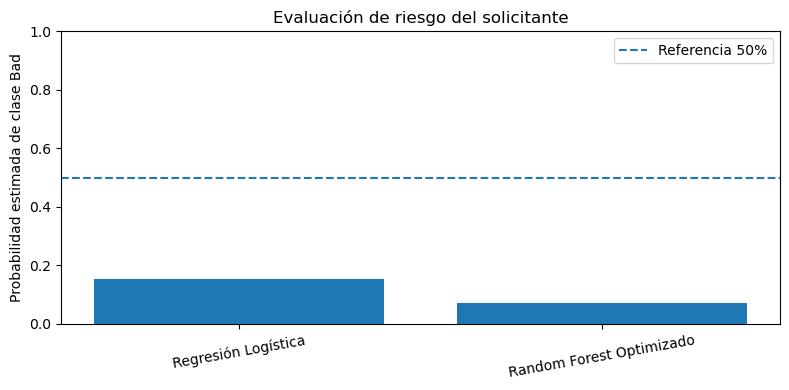

In [149]:
# ============================================================
# B6.8 - VISUALIZACIÓN DEL RESULTADO
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.bar(
    resultado_demo["Modelo"],
    resultado_demo["Probabilidad Bad"]
)

ax.axhline(
    y=0.50,
    linestyle="--",
    label="Referencia 50%"
)

ax.set_ylim(0, 1)

ax.set_ylabel(
    "Probabilidad estimada de clase Bad"
)

ax.set_title(
    "Evaluación de riesgo del solicitante"
)

ax.legend()

plt.xticks(
    rotation=10
)

plt.tight_layout()

plt.show()

In [150]:
# ============================================================
# B6.9 - VALIDACIÓN DEL PROTOTIPO
# ============================================================

print("VALIDACIÓN DEL BLOQUE 6")
print("=" * 55)

validaciones_b6 = {

    "Solicitante contiene 20 variables":
        len(solicitante_demo) == 20,

    "Dos modelos ejecutados":
        len(resultado_demo) == 2,

    "Probabilidades válidas":
        resultado_demo[
            "Probabilidad Bad"
        ].between(0, 1).all(),

    "Clasificaciones válidas":
        resultado_demo[
            "Clasificación"
        ].isin(
            ["Good", "Bad"]
        ).all(),

    "Consenso generado":
        consenso_demo in [
            "Good",
            "Bad",
            "Revisión"
        ]
}

for nombre, resultado in validaciones_b6.items():

    simbolo = (
        "✓"
        if resultado
        else "✗"
    )

    print(
        f"{simbolo} {nombre}"
    )


if all(
    validaciones_b6.values()
):

    print(
        "\nBLOQUE 6 COMPLETADO "
        "CORRECTAMENTE."
    )

else:

    print(
        "\nRevisar las validaciones "
        "antes de continuar."
    )

VALIDACIÓN DEL BLOQUE 6
✓ Solicitante contiene 20 variables
✓ Dos modelos ejecutados
✓ Probabilidades válidas
✓ Clasificaciones válidas
✓ Consenso generado

BLOQUE 6 COMPLETADO CORRECTAMENTE.


In [151]:
# ============================================================
# B7.1 - DICCIONARIOS DE CATEGORÍAS
# ============================================================

catalogos = {

    "checking_status": {
        "A11": "< 0 DM",
        "A12": "0 a < 200 DM",
        "A13": ">= 200 DM",
        "A14": "Sin cuenta corriente"
    },

    "credit_history": {
        "A30": "Sin créditos / créditos pagados",
        "A31": "Créditos pagados correctamente",
        "A32": "Créditos existentes pagados correctamente",
        "A33": "Retrasos en pagos anteriores",
        "A34": "Cuenta crítica / otros créditos existentes"
    },

    "purpose": {
        "A40": "Automóvil nuevo",
        "A41": "Automóvil usado",
        "A42": "Muebles / equipamiento",
        "A43": "Radio / televisión",
        "A44": "Electrodomésticos",
        "A45": "Reparaciones",
        "A46": "Educación",
        "A48": "Reentrenamiento",
        "A49": "Negocio",
        "A410": "Otros"
    },

    "savings_status": {
        "A61": "< 100 DM",
        "A62": "100 a < 500 DM",
        "A63": "500 a < 1000 DM",
        "A64": ">= 1000 DM",
        "A65": "Sin cuenta de ahorro"
    },

    "employment_since": {
        "A71": "Desempleado",
        "A72": "< 1 año",
        "A73": "1 a < 4 años",
        "A74": "4 a < 7 años",
        "A75": ">= 7 años"
    },

    "personal_status_sex": {
        "A91": "Hombre divorciado/separado",
        "A92": "Mujer divorciada/separada/casada",
        "A93": "Hombre soltero",
        "A94": "Hombre casado/viudo",
        "A95": "Mujer soltera"
    },

    "other_debtors": {
        "A101": "Ninguno",
        "A102": "Co-solicitante",
        "A103": "Garante"
    },

    "property_type": {
        "A121": "Bien inmueble",
        "A122": "Seguro de vida / ahorro",
        "A123": "Automóvil u otros bienes",
        "A124": "Sin propiedad"
    },

    "other_installment_plans": {
        "A141": "Banco",
        "A142": "Tiendas",
        "A143": "Ninguno"
    },

    "housing": {
        "A151": "Renta",
        "A152": "Propia",
        "A153": "Gratis"
    },

    "job": {
        "A171": "Desempleado / no calificado no residente",
        "A172": "No calificado residente",
        "A173": "Empleado calificado",
        "A174": "Profesional / directivo / autónomo"
    },

    "telephone": {
        "A191": "Sin teléfono registrado",
        "A192": "Teléfono registrado"
    },

    "foreign_worker": {
        "A201": "Sí",
        "A202": "No"
    }
}

print("CATÁLOGOS CONFIGURADOS")
print("=" * 50)
print(f"Variables categóricas documentadas: {len(catalogos)}")

CATÁLOGOS CONFIGURADOS
Variables categóricas documentadas: 13


In [152]:
# ============================================================
# B7.2 - PRESENTACIÓN LEGIBLE DEL SOLICITANTE
# ============================================================

def mostrar_solicitante(datos_solicitante):
    """
    Convierte los códigos del German Credit Data
    en descripciones más comprensibles.
    """

    registros = []

    for variable, valor in datos_solicitante.items():

        if variable in catalogos:

            descripcion = catalogos[
                variable
            ].get(
                valor,
                "Categoría no identificada"
            )

        else:

            descripcion = valor

        registros.append({
            "Variable": variable,
            "Valor": valor,
            "Descripción": descripcion
        })

    return pd.DataFrame(registros)

In [153]:
# ============================================================
# B7.3 - VISUALIZACIÓN DEL SOLICITANTE
# ============================================================

solicitante_legible = mostrar_solicitante(
    solicitante_demo
)

print("DATOS DEL SOLICITANTE")
print("=" * 55)

display(
    solicitante_legible
)

DATOS DEL SOLICITANTE


,Variable,Valor,Descripción
0,duration_months,6,6
1,credit_amount,1169,1169
2,installment_rate,4,4
3,residence_since,4,4
4,age,67,67
5,existing_credits,2,2
6,dependents,1,1
7,checking_status,A11,< 0 DM
8,credit_history,A34,Cuenta crítica / otros créditos existentes
9,purpose,A43,Radio / televisión


In [154]:
# ============================================================
# B7.4 - REPORTE EJECUTIVO DE CREDIT SCORING
# ============================================================

def reporte_crediticio(
    datos_solicitante
):
    """
    Ejecuta la evaluación crediticia completa
    y presenta un resultado ejecutivo.
    """

    resultado = evaluar_solicitante(
        datos_solicitante
    )

    consenso = obtener_consenso(
        resultado
    )

    print("\n" + "=" * 70)
    print("              REPORTE DE CREDIT SCORING")
    print("=" * 70)

    print("\nRESULTADOS DE LOS MODELOS")

    for _, fila in resultado.iterrows():

        print(
            f"\n{fila['Modelo']}"
        )

        print(
            f"Probabilidad estimada Bad: "
            f"{fila['Probabilidad Bad']:.2%}"
        )

        print(
            f"Umbral de clasificación: "
            f"{fila['Umbral']:.2f}"
        )

        print(
            f"Clasificación: "
            f"{fila['Clasificación']}"
        )

    print("\n" + "-" * 70)

    print(
        f"Resultado de consenso: "
        f"{consenso}"
    )

    print("=" * 70)

    return resultado, consenso

In [155]:
# ============================================================
# B7.5 - EJECUCIÓN DEL REPORTE CREDITICIO
# ============================================================

resultado_reporte, consenso_reporte = (
    reporte_crediticio(
        solicitante_demo
    )
)

✓ El solicitante contiene las 20 variables requeridas.
CONSENSO ENTRE MODELOS
✓ Ambos modelos clasifican al solicitante como: Good

              REPORTE DE CREDIT SCORING

RESULTADOS DE LOS MODELOS

Regresión Logística
Probabilidad estimada Bad: 15.36%
Umbral de clasificación: 0.50
Clasificación: Good

Random Forest Optimizado
Probabilidad estimada Bad: 7.22%
Umbral de clasificación: 0.55
Clasificación: Good

----------------------------------------------------------------------
Resultado de consenso: Good


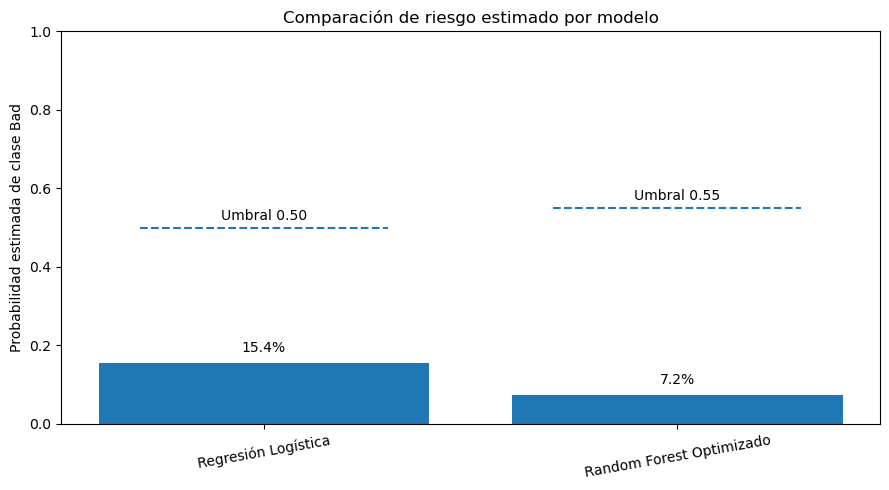

In [156]:
# ============================================================
# B7.6 - VISUALIZACIÓN DE PROBABILIDAD Y UMBRAL
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)

modelos = resultado_demo["Modelo"]
probabilidades = resultado_demo[
    "Probabilidad Bad"
]
umbrales_modelos = resultado_demo[
    "Umbral"
]

barras = ax.bar(
    modelos,
    probabilidades
)

for i, (
    probabilidad,
    umbral
) in enumerate(
    zip(
        probabilidades,
        umbrales_modelos
    )
):

    ax.hlines(
        y=umbral,
        xmin=i - 0.3,
        xmax=i + 0.3,
        linestyles="--"
    )

    ax.text(
        i,
        probabilidad + 0.03,
        f"{probabilidad:.1%}",
        ha="center"
    )

    ax.text(
        i,
        umbral + 0.02,
        f"Umbral {umbral:.2f}",
        ha="center"
    )

ax.set_ylim(
    0,
    1
)

ax.set_ylabel(
    "Probabilidad estimada de clase Bad"
)

ax.set_title(
    "Comparación de riesgo estimado por modelo"
)

plt.xticks(
    rotation=10
)

plt.tight_layout()

plt.show()

In [157]:
# ============================================================
# B7.7 - INTERPRETACIÓN AUTOMÁTICA
# ============================================================

def interpretar_resultado(
    consenso
):

    if consenso == "Good":

        mensaje = (
            "Los dos modelos clasifican al "
            "solicitante dentro de la categoría "
            "Good bajo los criterios del prototipo."
        )

    elif consenso == "Bad":

        mensaje = (
            "Los dos modelos clasifican al "
            "solicitante dentro de la categoría "
            "Bad bajo los criterios del prototipo."
        )

    else:

        mensaje = (
            "Los modelos presentan resultados "
            "diferentes. Se recomienda revisar "
            "el registro antes de establecer "
            "una clasificación final."
        )

    return mensaje


interpretacion_demo = interpretar_resultado(
    consenso_reporte
)

print("INTERPRETACIÓN DEL RESULTADO")
print("=" * 55)

print(
    interpretacion_demo
)

INTERPRETACIÓN DEL RESULTADO
Los dos modelos clasifican al solicitante dentro de la categoría Good bajo los criterios del prototipo.


In [158]:
# ============================================================
# B7.8 - EXPORTACIÓN DEL RESULTADO
# ============================================================

RESULTADOS_PATH = (
    BASE_PATH /
    "resultado_credit_scoring_demo.csv"
)

resultado_exportar = (
    resultado_demo.copy()
)

resultado_exportar[
    "Consenso"
] = consenso_reporte

resultado_exportar[
    "Interpretacion"
] = interpretacion_demo

resultado_exportar.to_csv(
    RESULTADOS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "RESULTADO EXPORTADO CORRECTAMENTE"
)

print(
    f"Archivo generado:\n"
    f"{RESULTADOS_PATH}"
)

RESULTADO EXPORTADO CORRECTAMENTE
Archivo generado:
C:\Users\LENOVO\Documents\Maestría Análisis y Visualización de Datos Masivos\Seminario de innovación en análisis y visualizaión de datos\Entregas\Códigos\resultado_credit_scoring_demo.csv


In [159]:
# ============================================================
# B7.9 - VALIDACIÓN FINAL DEL BLOQUE 7
# ============================================================

print("VALIDACIÓN DEL BLOQUE 7")
print("=" * 55)

validaciones_b7 = {

    "13 catálogos disponibles":
        len(catalogos) == 13,

    "Solicitante legible generado":
        len(solicitante_legible) == 20,

    "Resultado ejecutivo generado":
        len(resultado_reporte) == 2,

    "Consenso válido":
        consenso_reporte in [
            "Good",
            "Bad",
            "Revisión"
        ],

    "Interpretación generada":
        isinstance(
            interpretacion_demo,
            str
        )
        and len(
            interpretacion_demo
        ) > 0,

    "Archivo CSV generado":
        RESULTADOS_PATH.exists()
}

for nombre, resultado in validaciones_b7.items():

    simbolo = (
        "✓"
        if resultado
        else "✗"
    )

    print(
        f"{simbolo} {nombre}"
    )

if all(
    validaciones_b7.values()
):

    print(
        "\nBLOQUE 7 COMPLETADO "
        "CORRECTAMENTE."
    )

else:

    print(
        "\nRevisar las validaciones "
        "antes de continuar."
    )

VALIDACIÓN DEL BLOQUE 7
✓ 13 catálogos disponibles
✓ Solicitante legible generado
✓ Resultado ejecutivo generado
✓ Consenso válido
✓ Interpretación generada
✓ Archivo CSV generado

BLOQUE 7 COMPLETADO CORRECTAMENTE.


In [160]:
# ============================================================
# B8.1 - RUTAS DE PERSISTENCIA
# ============================================================

MODELO_LR_PATH = (
    BASE_PATH /
    "modelo_regresion_logistica.pkl"
)

MODELO_RF_PATH = (
    BASE_PATH /
    "modelo_random_forest_optimizado.pkl"
)

CONFIG_PATH = (
    BASE_PATH /
    "configuracion_prototipo.pkl"
)

print("RUTAS DE PERSISTENCIA")
print("=" * 55)

print(f"LR:     {MODELO_LR_PATH}")
print(f"RF:     {MODELO_RF_PATH}")
print(f"Config: {CONFIG_PATH}")

RUTAS DE PERSISTENCIA
LR:     C:\Users\LENOVO\Documents\Maestría Análisis y Visualización de Datos Masivos\Seminario de innovación en análisis y visualizaión de datos\Entregas\Códigos\modelo_regresion_logistica.pkl
RF:     C:\Users\LENOVO\Documents\Maestría Análisis y Visualización de Datos Masivos\Seminario de innovación en análisis y visualizaión de datos\Entregas\Códigos\modelo_random_forest_optimizado.pkl
Config: C:\Users\LENOVO\Documents\Maestría Análisis y Visualización de Datos Masivos\Seminario de innovación en análisis y visualizaión de datos\Entregas\Códigos\configuracion_prototipo.pkl


In [161]:
# ============================================================
# B8.2 - GUARDADO DE MODELOS
# ============================================================

with open(
    MODELO_LR_PATH,
    "wb"
) as archivo:
    pickle.dump(
        modelo_lr,
        archivo
    )

with open(
    MODELO_RF_PATH,
    "wb"
) as archivo:
    pickle.dump(
        modelo_rf_optimizado,
        archivo
    )

print("MODELOS GUARDADOS CORRECTAMENTE")
print("=" * 55)

print("✓ Regresión Logística guardada")
print("✓ Random Forest optimizado guardado")

MODELOS GUARDADOS CORRECTAMENTE
✓ Regresión Logística guardada
✓ Random Forest optimizado guardado


In [162]:
# ============================================================
# B8.3 - GUARDADO DE CONFIGURACIÓN
# ============================================================

configuracion_prototipo = {
    "umbral_lr": UMBRAL_LR,
    "umbral_rf": UMBRAL_RF,
    "variables_prototipo": variables_prototipo,
    "variables_lr": variables_lr,
    "random_state": RANDOM_STATE,
    "clase_positiva": "Bad",
    "codificacion_objetivo": {
        0: "Good",
        1: "Bad"
    }
}

with open(
    CONFIG_PATH,
    "wb"
) as archivo:
    pickle.dump(
        configuracion_prototipo,
        archivo
    )

print("CONFIGURACIÓN GUARDADA CORRECTAMENTE")
print("=" * 55)

for clave, valor in configuracion_prototipo.items():
    print(f"{clave}: {valor}")

CONFIGURACIÓN GUARDADA CORRECTAMENTE
umbral_lr: 0.5
umbral_rf: 0.55
variables_prototipo: ['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'dependents', 'checking_status', 'credit_history', 'purpose', 'savings_status', 'employment_since', 'personal_status_sex', 'other_debtors', 'property_type', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
variables_lr: ['checking_status', 'credit_history', 'duration_months', 'savings_status', 'purpose', 'credit_amount', 'residence_since', 'property_type']
random_state: 42
clase_positiva: Bad
codificacion_objetivo: {0: 'Good', 1: 'Bad'}


In [163]:
# ============================================================
# B8.4 - VALIDACIÓN DE ARCHIVOS
# ============================================================

print("VALIDACIÓN DE ARCHIVOS")
print("=" * 55)

archivos_modelo = {
    "Modelo LR":
        MODELO_LR_PATH,

    "Modelo RF":
        MODELO_RF_PATH,

    "Configuración":
        CONFIG_PATH
}

for nombre, ruta in archivos_modelo.items():

    existe = ruta.exists()

    simbolo = (
        "✓"
        if existe
        else "✗"
    )

    print(
        f"{simbolo} {nombre}: "
        f"{ruta.name}"
    )

VALIDACIÓN DE ARCHIVOS
✓ Modelo LR: modelo_regresion_logistica.pkl
✓ Modelo RF: modelo_random_forest_optimizado.pkl
✓ Configuración: configuracion_prototipo.pkl


In [164]:
# ============================================================
# B8.5 - CARGA DE MODELOS DESDE DISCO
# ============================================================

with open(
    MODELO_LR_PATH,
    "rb"
) as archivo:
    modelo_lr_cargado = pickle.load(
        archivo
    )

with open(
    MODELO_RF_PATH,
    "rb"
) as archivo:
    modelo_rf_cargado = pickle.load(
        archivo
    )

with open(
    CONFIG_PATH,
    "rb"
) as archivo:
    configuracion_cargada = pickle.load(
        archivo
    )

print("MODELOS Y CONFIGURACIÓN CARGADOS")
print("=" * 55)

print(
    f"Umbral LR: "
    f"{configuracion_cargada['umbral_lr']}"
)

print(
    f"Umbral RF: "
    f"{configuracion_cargada['umbral_rf']}"
)

print(
    "\n✓ Los objetos persistidos "
    "fueron recuperados correctamente."
)

MODELOS Y CONFIGURACIÓN CARGADOS
Umbral LR: 0.5
Umbral RF: 0.55

✓ Los objetos persistidos fueron recuperados correctamente.


In [165]:
# ============================================================
# B8.6 - SCORING CON MODELOS CARGADOS
# ============================================================

def evaluar_solicitante_cargado(
    datos_solicitante
):

    nuevo = pd.DataFrame(
        [datos_solicitante]
    )

    nuevo = nuevo[
        configuracion_cargada[
            "variables_prototipo"
        ]
    ]

    probabilidad_lr = (
        modelo_lr_cargado
        .predict_proba(
            nuevo
        )[:, 1][0]
    )

    probabilidad_rf = (
        modelo_rf_cargado
        .predict_proba(
            nuevo
        )[:, 1][0]
    )

    umbral_lr = (
        configuracion_cargada[
            "umbral_lr"
        ]
    )

    umbral_rf = (
        configuracion_cargada[
            "umbral_rf"
        ]
    )

    clase_lr = (
        "Bad"
        if probabilidad_lr >= umbral_lr
        else "Good"
    )

    clase_rf = (
        "Bad"
        if probabilidad_rf >= umbral_rf
        else "Good"
    )

    return pd.DataFrame({
        "Modelo": [
            "Regresión Logística",
            "Random Forest Optimizado"
        ],

        "Probabilidad Bad": [
            probabilidad_lr,
            probabilidad_rf
        ],

        "Umbral": [
            umbral_lr,
            umbral_rf
        ],

        "Clasificación": [
            clase_lr,
            clase_rf
        ]
    })

In [168]:
# ============================================================
# B8.7 - REEJECUCIÓN CON MODELOS CARGADOS
# ============================================================

resultado_cargado = (
    evaluar_solicitante_cargado(
        solicitante_demo
    )
)

print("RESULTADO CON MODELOS CARGADOS")
print("=" * 55)

display(
    resultado_cargado.style.format({
        "Probabilidad Bad": "{:.2%}",
        "Umbral": "{:.2f}"
    })
)

RESULTADO CON MODELOS CARGADOS


,Modelo,Probabilidad Bad,Umbral,Clasificación
0,Regresión Logística,15.36%,0.50,Good
1,Random Forest Optimizado,7.22%,0.55,Good


In [169]:
# ============================================================
# B8.8 - COMPARACIÓN DE CONSISTENCIA
# ============================================================

comparacion_persistencia = pd.DataFrame({
    "Modelo": resultado_demo[
        "Modelo"
    ],

    "Probabilidad original":
        resultado_demo[
            "Probabilidad Bad"
        ],

    "Probabilidad cargada":
        resultado_cargado[
            "Probabilidad Bad"
        ],

    "Clasificación original":
        resultado_demo[
            "Clasificación"
        ],

    "Clasificación cargada":
        resultado_cargado[
            "Clasificación"
        ]
})

comparacion_persistencia[
    "Diferencia"
] = (
    comparacion_persistencia[
        "Probabilidad original"
    ]
    -
    comparacion_persistencia[
        "Probabilidad cargada"
    ]
).abs()

display(
    comparacion_persistencia.style.format({
        "Probabilidad original": "{:.4%}",
        "Probabilidad cargada": "{:.4%}",
        "Diferencia": "{:.10f}"
    })
)

,Modelo,Probabilidad original,Probabilidad cargada,Clasificación original,Clasificación cargada,Diferencia
0,Regresión Logística,15.3591%,15.3591%,Good,Good,0.0000000000
1,Random Forest Optimizado,7.2201%,7.2201%,Good,Good,0.0000000000


In [170]:
# ============================================================
# B8.9 - VALIDACIÓN DE REPRODUCIBILIDAD
# ============================================================

probabilidades_iguales = np.allclose(
    resultado_demo[
        "Probabilidad Bad"
    ].values,

    resultado_cargado[
        "Probabilidad Bad"
    ].values,

    rtol=1e-10,
    atol=1e-12
)

clasificaciones_iguales = (
    resultado_demo[
        "Clasificación"
    ].tolist()
    ==
    resultado_cargado[
        "Clasificación"
    ].tolist()
)

print("VALIDACIÓN DE REPRODUCIBILIDAD")
print("=" * 55)

print(
    "✓ Probabilidades idénticas"
    if probabilidades_iguales
    else
    "✗ Las probabilidades cambiaron"
)

print(
    "✓ Clasificaciones idénticas"
    if clasificaciones_iguales
    else
    "✗ Las clasificaciones cambiaron"
)

VALIDACIÓN DE REPRODUCIBILIDAD
✓ Probabilidades idénticas
✓ Clasificaciones idénticas


In [171]:
# ============================================================
# B8.10 - VALIDACIÓN FINAL DEL BLOQUE 8
# ============================================================

print("VALIDACIÓN DEL BLOQUE 8")
print("=" * 55)

validaciones_b8 = {

    "Archivo LR guardado":
        MODELO_LR_PATH.exists(),

    "Archivo RF guardado":
        MODELO_RF_PATH.exists(),

    "Configuración guardada":
        CONFIG_PATH.exists(),

    "Modelo LR cargado":
        modelo_lr_cargado is not None,

    "Modelo RF cargado":
        modelo_rf_cargado is not None,

    "Probabilidades reproducibles":
        probabilidades_iguales,

    "Clasificaciones reproducibles":
        clasificaciones_iguales
}

for nombre, resultado in validaciones_b8.items():

    simbolo = (
        "✓"
        if resultado
        else "✗"
    )

    print(
        f"{simbolo} {nombre}"
    )

if all(
    validaciones_b8.values()
):

    print(
        "\nBLOQUE 8 COMPLETADO "
        "CORRECTAMENTE."
    )

else:

    print(
        "\nRevisar las validaciones "
        "antes de continuar."
    )

VALIDACIÓN DEL BLOQUE 8
✓ Archivo LR guardado
✓ Archivo RF guardado
✓ Configuración guardada
✓ Modelo LR cargado
✓ Modelo RF cargado
✓ Probabilidades reproducibles
✓ Clasificaciones reproducibles

BLOQUE 8 COMPLETADO CORRECTAMENTE.


In [2]:
# ============================================================
# ARRANQUE OPERATIVO DEL PROTOTIPO
# ============================================================

import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output

BASE_PATH = Path(
    r"C:\Users\LENOVO\Documents\Maestría Análisis y Visualización de Datos Masivos\Seminario de innovación en análisis y visualizaión de datos\Entregas\Códigos"
)

MODELO_LR_PATH = BASE_PATH / "modelo_regresion_logistica.pkl"
MODELO_RF_PATH = BASE_PATH / "modelo_random_forest_optimizado.pkl"
CONFIG_PATH = BASE_PATH / "configuracion_prototipo.pkl"

with open(MODELO_LR_PATH, "rb") as archivo:
    modelo_lr_cargado = pickle.load(archivo)

with open(MODELO_RF_PATH, "rb") as archivo:
    modelo_rf_cargado = pickle.load(archivo)

with open(CONFIG_PATH, "rb") as archivo:
    configuracion_cargada = pickle.load(archivo)

print("PROTOTIPO OPERATIVO CARGADO")
print("=" * 55)
print("✓ Modelo LR cargado")
print("✓ Modelo RF cargado")
print("✓ Configuración cargada")

PROTOTIPO OPERATIVO CARGADO
✓ Modelo LR cargado
✓ Modelo RF cargado
✓ Configuración cargada


In [3]:
# ============================================================
# INICIALIZACIÓN DE DATOS Y CATÁLOGOS PARA LA INTERFAZ
# ============================================================

# Ruta del dataset
DATA_PATH = BASE_PATH / "german.csv"

# Nombres de las 20 variables predictoras
columnas = [
    "checking_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_status",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property_type",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker",
    "target"
]

# Carga del dataset
df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=columnas
)

# ============================================================
# CATÁLOGOS DE VARIABLES CATEGÓRICAS
# ============================================================

catalogos = {

    "checking_status": {
        "A11": "< 0 DM",
        "A12": "0 a < 200 DM",
        "A13": ">= 200 DM",
        "A14": "Sin cuenta corriente"
    },

    "credit_history": {
        "A30": "Sin créditos / créditos pagados",
        "A31": "Todos los créditos pagados correctamente",
        "A32": "Créditos existentes pagados correctamente",
        "A33": "Retrasos anteriores",
        "A34": "Cuenta crítica / otros créditos existentes"
    },

    "purpose": {
        "A40": "Automóvil nuevo",
        "A41": "Automóvil usado",
        "A42": "Muebles / equipamiento",
        "A43": "Radio / televisión",
        "A44": "Electrodomésticos",
        "A45": "Reparaciones",
        "A46": "Educación",
        "A48": "Reentrenamiento",
        "A49": "Negocio",
        "A410": "Otros"
    },

    "savings_status": {
        "A61": "< 100 DM",
        "A62": "100 a < 500 DM",
        "A63": "500 a < 1000 DM",
        "A64": ">= 1000 DM",
        "A65": "Sin cuenta de ahorro"
    },

    "employment_since": {
        "A71": "Desempleado",
        "A72": "< 1 año",
        "A73": "1 a < 4 años",
        "A74": "4 a < 7 años",
        "A75": ">= 7 años"
    },

    "personal_status_sex": {
        "A91": "Hombre divorciado/separado",
        "A92": "Mujer divorciada/separada/casada",
        "A93": "Hombre soltero",
        "A94": "Hombre casado/viudo",
        "A95": "Mujer soltera"
    },

    "other_debtors": {
        "A101": "Ninguno",
        "A102": "Co-solicitante",
        "A103": "Garante"
    },

    "property_type": {
        "A121": "Bien inmueble",
        "A122": "Seguro de vida / ahorro",
        "A123": "Automóvil u otra propiedad",
        "A124": "Sin propiedad"
    },

    "other_installment_plans": {
        "A141": "Banco",
        "A142": "Tienda",
        "A143": "Ninguno"
    },

    "housing": {
        "A151": "Renta",
        "A152": "Propia",
        "A153": "Sin costo"
    },

    "job": {
        "A171": "Desempleado / no calificado no residente",
        "A172": "No calificado residente",
        "A173": "Empleado calificado",
        "A174": "Gerencia / autónomo / altamente calificado"
    },

    "telephone": {
        "A191": "Sin teléfono registrado",
        "A192": "Teléfono registrado"
    },

    "foreign_worker": {
        "A201": "Sí",
        "A202": "No"
    }
}

print("INICIALIZACIÓN OPERATIVA COMPLETADA")
print("=" * 55)
print(f"✓ Dataset cargado: {len(df)} registros")
print("✓ 20 variables predictoras disponibles")
print(f"✓ {len(catalogos)} catálogos disponibles")
print("✓ No se realizó ningún entrenamiento")

INICIALIZACIÓN OPERATIVA COMPLETADA
✓ Dataset cargado: 1000 registros
✓ 20 variables predictoras disponibles
✓ 13 catálogos disponibles
✓ No se realizó ningún entrenamiento


In [12]:
# ============================================================
# FUNCIÓN DE VALIDACIÓN PARA MODO OPERATIVO
# ============================================================

variables_prototipo = (
    configuracion_cargada[
        "variables_prototipo"
    ]
)

def validar_solicitante(datos_solicitante):
    """
    Valida que el registro contenga exactamente
    las variables requeridas por el prototipo.
    """

    variables_recibidas = set(
        datos_solicitante.keys()
    )

    variables_requeridas = set(
        variables_prototipo
    )

    faltantes = (
        variables_requeridas -
        variables_recibidas
    )

    adicionales = (
        variables_recibidas -
        variables_requeridas
    )

    if faltantes:

        print("✗ Faltan variables requeridas:")

        for variable in sorted(faltantes):
            print(f" - {variable}")

        return False

    if adicionales:

        print(
            "Advertencia: existen variables adicionales:"
        )

        for variable in sorted(adicionales):
            print(f" - {variable}")

    print(
        "✓ El solicitante contiene "
        "las 20 variables requeridas."
    )

    return True


print(
    "✓ Función validar_solicitante "
    "disponible en modo operativo."
)

✓ Función validar_solicitante disponible en modo operativo.


In [4]:
# ============================================================
# B9.2 - CONFIGURACIÓN DE CAMPOS DEL FORMULARIO
# ============================================================

def rango_numerico(variable):
    """
    Obtiene mínimo, máximo y mediana
    observados en el dataset original.
    """

    minimo = int(df[variable].min())
    maximo = int(df[variable].max())
    mediana = int(df[variable].median())

    return minimo, maximo, mediana


def opciones_catalogo(variable):
    """
    Convierte cada catálogo al formato:
    (descripción visible, código interno)
    """

    return [
        (descripcion, codigo)
        for codigo, descripcion
        in catalogos[variable].items()
    ]


print("Funciones auxiliares configuradas.")

Funciones auxiliares configuradas.


In [5]:
# ============================================================
# B9.3 - CAMPOS NUMÉRICOS DEL FORMULARIO
# ============================================================

min_duration, max_duration, med_duration = rango_numerico(
    "duration_months"
)

min_amount, max_amount, med_amount = rango_numerico(
    "credit_amount"
)

min_installment, max_installment, med_installment = rango_numerico(
    "installment_rate"
)

min_residence, max_residence, med_residence = rango_numerico(
    "residence_since"
)

min_age, max_age, med_age = rango_numerico(
    "age"
)

min_credits, max_credits, med_credits = rango_numerico(
    "existing_credits"
)

min_dependents, max_dependents, med_dependents = rango_numerico(
    "dependents"
)


w_duration = widgets.IntSlider(
    value=med_duration,
    min=min_duration,
    max=max_duration,
    step=1,
    description="Duración:",
    continuous_update=False
)

w_amount = widgets.IntText(
    value=med_amount,
    description="Monto:"
)

w_installment = widgets.IntSlider(
    value=med_installment,
    min=min_installment,
    max=max_installment,
    step=1,
    description="Cuota:"
)

w_residence = widgets.IntSlider(
    value=med_residence,
    min=min_residence,
    max=max_residence,
    step=1,
    description="Residencia:"
)

w_age = widgets.IntSlider(
    value=med_age,
    min=min_age,
    max=max_age,
    step=1,
    description="Edad:"
)

w_existing_credits = widgets.IntSlider(
    value=med_credits,
    min=min_credits,
    max=max_credits,
    step=1,
    description="Créditos:"
)

w_dependents = widgets.IntSlider(
    value=med_dependents,
    min=min_dependents,
    max=max_dependents,
    step=1,
    description="Dependientes:"
)

print("Campos numéricos configurados.")

Campos numéricos configurados.


In [6]:
# ============================================================
# B9.4 - CAMPOS CATEGÓRICOS DEL FORMULARIO
# ============================================================

w_checking = widgets.Dropdown(
    options=opciones_catalogo("checking_status"),
    description="Cuenta:"
)

w_history = widgets.Dropdown(
    options=opciones_catalogo("credit_history"),
    description="Historial:"
)

w_purpose = widgets.Dropdown(
    options=opciones_catalogo("purpose"),
    description="Propósito:"
)

w_savings = widgets.Dropdown(
    options=opciones_catalogo("savings_status"),
    description="Ahorro:"
)

w_employment = widgets.Dropdown(
    options=opciones_catalogo("employment_since"),
    description="Empleo:"
)

w_personal = widgets.Dropdown(
    options=opciones_catalogo("personal_status_sex"),
    description="Situación:"
)

w_debtors = widgets.Dropdown(
    options=opciones_catalogo("other_debtors"),
    description="Deudores:"
)

w_property = widgets.Dropdown(
    options=opciones_catalogo("property_type"),
    description="Propiedad:"
)

w_installment_plans = widgets.Dropdown(
    options=opciones_catalogo("other_installment_plans"),
    description="Otros pagos:"
)

w_housing = widgets.Dropdown(
    options=opciones_catalogo("housing"),
    description="Vivienda:"
)

w_job = widgets.Dropdown(
    options=opciones_catalogo("job"),
    description="Trabajo:"
)

w_telephone = widgets.Dropdown(
    options=opciones_catalogo("telephone"),
    description="Teléfono:"
)

w_foreign = widgets.Dropdown(
    options=opciones_catalogo("foreign_worker"),
    description="Extranjero:"
)

print("Campos categóricos configurados.")

Campos categóricos configurados.


In [7]:
# ============================================================
# B9.5 - CONSTRUCCIÓN DEL REGISTRO DEL SOLICITANTE
# ============================================================

def obtener_datos_formulario():

    datos = {

        "duration_months":
            w_duration.value,

        "credit_amount":
            w_amount.value,

        "installment_rate":
            w_installment.value,

        "residence_since":
            w_residence.value,

        "age":
            w_age.value,

        "existing_credits":
            w_existing_credits.value,

        "dependents":
            w_dependents.value,

        "checking_status":
            w_checking.value,

        "credit_history":
            w_history.value,

        "purpose":
            w_purpose.value,

        "savings_status":
            w_savings.value,

        "employment_since":
            w_employment.value,

        "personal_status_sex":
            w_personal.value,

        "other_debtors":
            w_debtors.value,

        "property_type":
            w_property.value,

        "other_installment_plans":
            w_installment_plans.value,

        "housing":
            w_housing.value,

        "job":
            w_job.value,

        "telephone":
            w_telephone.value,

        "foreign_worker":
            w_foreign.value
    }

    return datos


print("Función de captura configurada.")

Función de captura configurada.


In [8]:
# ============================================================
# B9.6 - MOTOR DE EVALUACIÓN DE LA INTERFAZ
# ============================================================

def evaluar_desde_interfaz(datos):

    nuevo = pd.DataFrame(
        [datos]
    )

    nuevo = nuevo[
        configuracion_cargada[
            "variables_prototipo"
        ]
    ]

    # -------------------------------
    # Regresión Logística
    # -------------------------------

    prob_lr_ui = (
        modelo_lr_cargado
        .predict_proba(nuevo)[:, 1][0]
    )

    umbral_lr_ui = (
        configuracion_cargada[
            "umbral_lr"
        ]
    )

    clase_lr_ui = (
        "Bad"
        if prob_lr_ui >= umbral_lr_ui
        else "Good"
    )

    # -------------------------------
    # Random Forest
    # -------------------------------

    prob_rf_ui = (
        modelo_rf_cargado
        .predict_proba(nuevo)[:, 1][0]
    )

    umbral_rf_ui = (
        configuracion_cargada[
            "umbral_rf"
        ]
    )

    clase_rf_ui = (
        "Bad"
        if prob_rf_ui >= umbral_rf_ui
        else "Good"
    )

    resultado = pd.DataFrame({

        "Modelo": [
            "Regresión Logística",
            "Random Forest Optimizado"
        ],

        "Probabilidad Bad": [
            prob_lr_ui,
            prob_rf_ui
        ],

        "Umbral": [
            umbral_lr_ui,
            umbral_rf_ui
        ],

        "Clasificación": [
            clase_lr_ui,
            clase_rf_ui
        ]
    })

    return resultado

In [9]:
# ============================================================
# B9.7 - BOTONES Y ÁREA DE RESULTADOS
# ============================================================

boton_evaluar = widgets.Button(
    description="Evaluar solicitante",
    button_style="success",
    icon="check"
)

boton_limpiar = widgets.Button(
    description="Limpiar resultado",
    button_style="warning",
    icon="trash"
)

salida_scoring = widgets.Output()

print("Controles de evaluación configurados.")

Controles de evaluación configurados.


In [13]:
# ============================================================
# B9.8 - ACCIÓN DEL BOTÓN EVALUAR
# ============================================================

def al_evaluar(b):

    with salida_scoring:

        clear_output()

        try:

            datos_cliente = (
                obtener_datos_formulario()
            )

            valido = validar_solicitante(
                datos_cliente
            )

            if not valido:
                return

            resultado_cliente = (
                evaluar_desde_interfaz(
                    datos_cliente
                )
            )

            clases = (
                resultado_cliente[
                    "Clasificación"
                ].tolist()
            )

            if clases[0] == clases[1]:
                consenso = clases[0]
            else:
                consenso = "Revisión"

            print("=" * 65)
            print("        RESULTADO DE CREDIT SCORING")
            print("=" * 65)

            display(
                resultado_cliente.style.format({
                    "Probabilidad Bad": "{:.2%}",
                    "Umbral": "{:.2f}"
                })
            )

            print("\nRESULTADO DE CONSENSO")
            print("-" * 40)

            print(
                f"{consenso}"
            )

            # --------------------------
            # Visualización
            # --------------------------

            fig, ax = plt.subplots(
                figsize=(8, 4)
            )

            probabilidades = (
                resultado_cliente[
                    "Probabilidad Bad"
                ]
            )

            modelos = (
                resultado_cliente[
                    "Modelo"
                ]
            )

            umbrales_ui = (
                resultado_cliente[
                    "Umbral"
                ]
            )

            ax.bar(
                modelos,
                probabilidades
            )

            for i, (
                probabilidad,
                umbral
            ) in enumerate(
                zip(
                    probabilidades,
                    umbrales_ui
                )
            ):

                ax.hlines(
                    y=umbral,
                    xmin=i - 0.3,
                    xmax=i + 0.3,
                    linestyles="--"
                )

                ax.text(
                    i,
                    probabilidad + 0.03,
                    f"{probabilidad:.1%}",
                    ha="center"
                )

                ax.text(
                    i,
                    umbral + 0.02,
                    f"Umbral {umbral:.2f}",
                    ha="center"
                )

            ax.set_ylim(
                0,
                1
            )

            ax.set_ylabel(
                "Probabilidad estimada Bad"
            )

            ax.set_title(
                "Evaluación crediticia del solicitante"
            )

            plt.xticks(
                rotation=10
            )

            plt.tight_layout()
            plt.show()

        except Exception as error:

            print(
                "ERROR DURANTE LA EVALUACIÓN"
            )

            print(
                str(error)
            )


def al_limpiar(b):

    with salida_scoring:

        clear_output()


boton_evaluar.on_click(
    al_evaluar
)

boton_limpiar.on_click(
    al_limpiar
)

print("Eventos de los botones configurados.")

Eventos de los botones configurados.


In [14]:
# ============================================================
# B9.9 - FORMULARIO INTERACTIVO
# ============================================================

titulo_formulario = widgets.HTML(
    value="""
    <h2>Prototipo de Credit Scoring</h2>
    <p>
    Capture la información del solicitante y
    presione <b>Evaluar solicitante</b>.
    </p>
    """
)

titulo_numericas = widgets.HTML(
    value="<h3>Información cuantitativa</h3>"
)

titulo_categoricas = widgets.HTML(
    value="<h3>Información del perfil crediticio</h3>"
)


columna_numerica_1 = widgets.VBox([
    w_duration,
    w_amount,
    w_installment,
    w_residence
])

columna_numerica_2 = widgets.VBox([
    w_age,
    w_existing_credits,
    w_dependents
])

panel_numerico = widgets.HBox([
    columna_numerica_1,
    columna_numerica_2
])


columna_cat_1 = widgets.VBox([
    w_checking,
    w_history,
    w_purpose,
    w_savings,
    w_employment,
    w_personal,
    w_debtors
])

columna_cat_2 = widgets.VBox([
    w_property,
    w_installment_plans,
    w_housing,
    w_job,
    w_telephone,
    w_foreign
])

panel_categorico = widgets.HBox([
    columna_cat_1,
    columna_cat_2
])


botones = widgets.HBox([
    boton_evaluar,
    boton_limpiar
])


formulario_credito = widgets.VBox([
    titulo_formulario,

    titulo_numericas,
    panel_numerico,

    titulo_categoricas,
    panel_categorico,

    widgets.HTML(
        value="<br>"
    ),

    botones,

    widgets.HTML(
        value="<hr>"
    ),

    salida_scoring
])


display(
    formulario_credito
)

In [15]:
# ============================================================
# B9.10 - VALIDACIÓN FINAL DEL BLOQUE 9
# ============================================================

print("VALIDACIÓN DEL BLOQUE 9")
print("=" * 55)

datos_formulario_prueba = obtener_datos_formulario()

resultado_prueba_interfaz = evaluar_desde_interfaz(
    datos_formulario_prueba
)

validaciones_b9 = {

    "20 variables capturadas":
        len(datos_formulario_prueba) == 20,

    "Modelo LR disponible":
        modelo_lr_cargado is not None,

    "Modelo RF disponible":
        modelo_rf_cargado is not None,

    "Configuración disponible":
        configuracion_cargada is not None,

    "Dos modelos ejecutados":
        len(resultado_prueba_interfaz) == 2,

    "Probabilidades válidas":
        resultado_prueba_interfaz[
            "Probabilidad Bad"
        ].between(0, 1).all(),

    "Clasificaciones válidas":
        resultado_prueba_interfaz[
            "Clasificación"
        ].isin(
            ["Good", "Bad"]
        ).all(),

    "Formulario construido":
        formulario_credito is not None
}

for nombre, resultado in validaciones_b9.items():

    simbolo = "✓" if resultado else "✗"

    print(
        f"{simbolo} {nombre}"
    )

if all(validaciones_b9.values()):

    print(
        "\nBLOQUE 9 COMPLETADO "
        "CORRECTAMENTE."
    )

else:

    print(
        "\nRevisar las validaciones "
        "antes de continuar."
    )

VALIDACIÓN DEL BLOQUE 9
✓ 20 variables capturadas
✓ Modelo LR disponible
✓ Modelo RF disponible
✓ Configuración disponible
✓ Dos modelos ejecutados
✓ Probabilidades válidas
✓ Clasificaciones válidas
✓ Formulario construido

BLOQUE 9 COMPLETADO CORRECTAMENTE.
